In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("loan_train.csv")
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [4]:
pd.read_csv("loan_train.csv")

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,486,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,1
487,487,LP001790,Female,No,1,Graduate,No,3812,0.0,112.0,360.0,1.0,Rural,1
488,488,LP001401,Male,Yes,1,Graduate,No,14583,0.0,185.0,180.0,1.0,Rural,1
489,489,LP002893,Male,No,0,Graduate,No,1836,33837.0,90.0,360.0,1.0,Urban,0


In [5]:
df.isnull().sum()

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
Unnamed: 0

In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Married"].fillna(df["Married"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)

df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median(), inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

C:\Users\tanvi\AppData\Local\Temp\ipykernel_24412\3428676217.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
C:\Users\tanvi\AppData\Local\Temp\ipykernel_24412\3428676217.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
486    1.0
487    1.0
488    1.0
489    1.0
490    1.0
Name: Credit_History, Length: 491, dtype: float64

In [9]:
df.isnull().sum()

Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df = df.drop(columns=["Loan_ID"])

In [11]:
# Categorical columns → fill with mode
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Married"].fillna(df["Married"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

# Numerical columns → fill with median
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median(), inplace=True)

C:\Users\tanvi\AppData\Local\Temp\ipykernel_24412\2487666462.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
C:\Users\tanvi\AppData\Local\Temp\ipykernel_24412\2487666462.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

0      360.0
1      360.0
2      360.0
3      360.0
4      300.0
       ...  
486    180.0
487    360.0
488    180.0
489    360.0
490    360.0
Name: Loan_Amount_Term, Length: 491, dtype: float64

In [12]:
df.isnull().sum()

Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
# Categorical columns
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Married"].fillna(df["Married"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

# Numerical columns
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median(), inplace=True)

C:\Users\tanvi\AppData\Local\Temp\ipykernel_24412\366195662.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
C:\Users\tanvi\AppData\Local\Temp\ipykernel_24412\366195662.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained ass

0      360.0
1      360.0
2      360.0
3      360.0
4      300.0
       ...  
486    180.0
487    360.0
488    180.0
489    360.0
490    360.0
Name: Loan_Amount_Term, Length: 491, dtype: float64

In [15]:
df.isnull().sum()

Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
# Categorical columns
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

# Numerical columns
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

In [17]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [18]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

In [19]:
# Fix Dependents
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = df["Dependents"].astype(int)

# Encode Property Area
df["Property_Area"] = df["Property_Area"].map({
    "Rural": 0,
    "Semiurban": 1,
    "Urban": 2
})

In [20]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
df.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status          float64
dtype: object

In [24]:
df["Loan_Status"].unique()

array([nan])

In [25]:
df = pd.read_csv("loan_train.csv")

In [26]:
# Fill categorical columns
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

# Fill numerical columns
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

In [27]:
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})
df["Married"] = df["Married"].map({"Yes":1, "No":0})
df["Education"] = df["Education"].map({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes":1, "No":0})
df["Loan_Status"] = df["Loan_Status"].map({"Y":1, "N":0})

df["Dependents"] = df["Dependents"].replace("3+",3).astype(int)
df["Property_Area"] = df["Property_Area"].map({
    "Rural":0,
    "Semiurban":1,
    "Urban":2
})

In [28]:
df["Loan_Status"].unique()

array([nan])

In [29]:
import pandas as pd

df = pd.read_csv("loan_train.csv")
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [30]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

In [31]:
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})
df["Married"] = df["Married"].map({"Yes":1, "No":0})
df["Education"] = df["Education"].map({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes":1, "No":0})
df["Loan_Status"] = df["Loan_Status"].map({"Y":1, "N":0})

df["Dependents"] = df["Dependents"].replace("3+",3).astype(int)
df["Property_Area"] = df["Property_Area"].map({
    "Rural":0,
    "Semiurban":1,
    "Urban":2
})

In [32]:
df["Loan_Status"].unique()

array([nan])

In [33]:
df = pd.read_csv("loan_train.csv")

In [34]:
import pandas as pd

In [35]:
df = pd.read_csv("loan_train.csv")
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [36]:
df["Loan_Status"].unique()

array([1, 0])

In [37]:
df = df.drop(["Loan_ID", "Unnamed: 0"], axis=1)

In [38]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
df = df.drop(columns=["Loan_ID", "Unnamed: 0"], errors="ignore")

In [42]:
df.dtypes

Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status            int64
dtype: object

In [44]:
df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = pd.to_numeric(df["Dependents"])

In [45]:
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})
df["Married"] = df["Married"].map({"Yes":1, "No":0})
df["Education"] = df["Education"].map({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes":1, "No":0})

df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = pd.to_numeric(df["Dependents"])

df["Property_Area"] = df["Property_Area"].map({
    "Rural":0,
    "Semiurban":1,
    "Urban":2
})

In [46]:
df.dtypes

Gender               float64
Married              float64
Dependents           float64
Education            float64
Self_Employed        float64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object

In [47]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
X.isnull().sum()

Gender               491
Married              491
Dependents             9
Education            491
Self_Employed        491
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            16
Loan_Amount_Term      13
Credit_History        43
Property_Area          0
dtype: int64

In [51]:
df["Gender"] = df["Gender"].replace({"Male":1, "Female":0})
df["Married"] = df["Married"].replace({"Yes":1, "No":0})
df["Education"] = df["Education"].replace({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].replace({"Yes":1, "No":0})

df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = pd.to_numeric(df["Dependents"])

df["Property_Area"] = df["Property_Area"].replace({
    "Rural":0,
    "Semiurban":1,
    "Urban":2
})

In [52]:
import pandas as pd

df = pd.read_csv("loan_train.csv")
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [53]:
df["Gender"] = df["Gender"].replace({"Male":1, "Female":0})
df["Married"] = df["Married"].replace({"Yes":1, "No":0})
df["Education"] = df["Education"].replace({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].replace({"Yes":1, "No":0})

df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = pd.to_numeric(df["Dependents"])

df["Property_Area"] = df["Property_Area"].replace({
    "Rural":0,
    "Semiurban":1,
    "Urban":2
})

In [55]:
# Fill missing numerical values
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [56]:
df.isnull().sum()

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [57]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

In [58]:
df.isnull().sum()

Unnamed: 0           0
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [59]:
df["Gender"] = df["Gender"].replace({"Male":1, "Female":0})
df["Married"] = df["Married"].replace({"Yes":1, "No":0})
df["Education"] = df["Education"].replace({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].replace({"Yes":1, "No":0})

df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = pd.to_numeric(df["Dependents"])

df["Property_Area"] = df["Property_Area"].replace({
    "Rural":0,
    "Semiurban":1,
    "Urban":2
})

In [61]:
df = df.drop(["Loan_ID", "Unnamed: 0"], axis=1)

In [62]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\tanvi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8282828282828283

In [64]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[17, 17],
       [ 0, 65]])

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        34
           1       0.79      1.00      0.88        65

    accuracy                           0.83        99
   macro avg       0.90      0.75      0.78        99
weighted avg       0.86      0.83      0.81        99



In [66]:
import joblib

joblib.dump(model, "loan_model.pkl")

['loan_model.pkl']

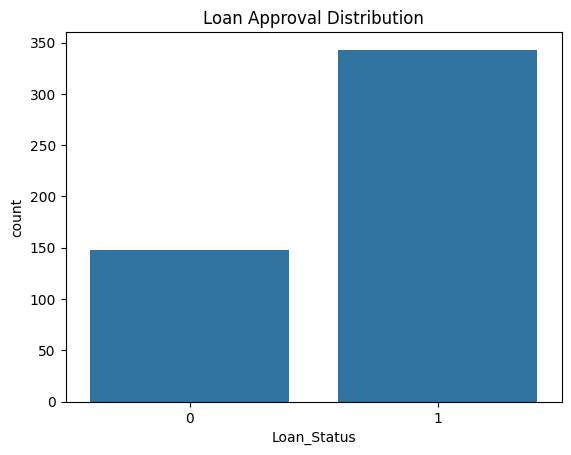

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

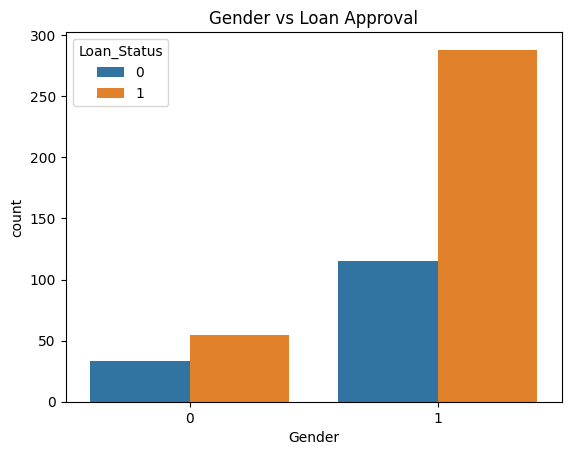

In [69]:
sns.countplot(x="Gender", hue="Loan_Status", data=df)
plt.title("Gender vs Loan Approval")
plt.show()

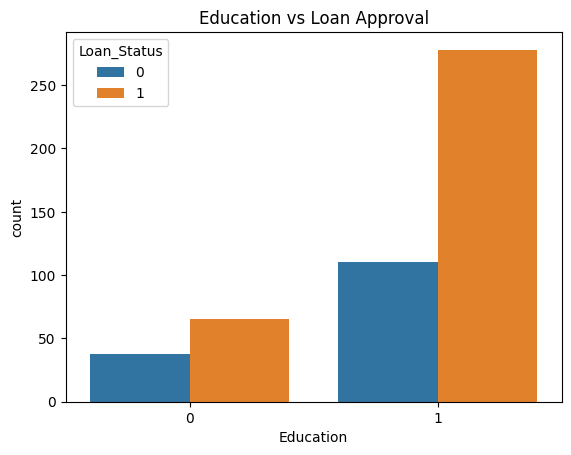

In [70]:
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education vs Loan Approval")
plt.show()

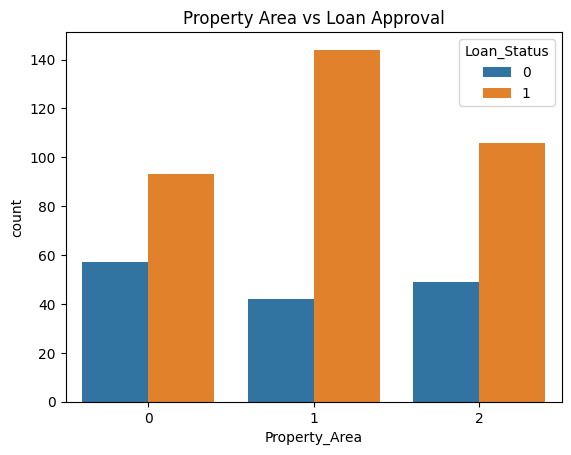

In [71]:
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

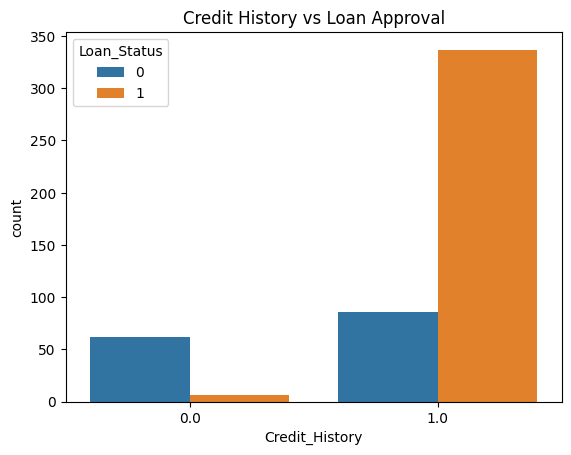

In [72]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

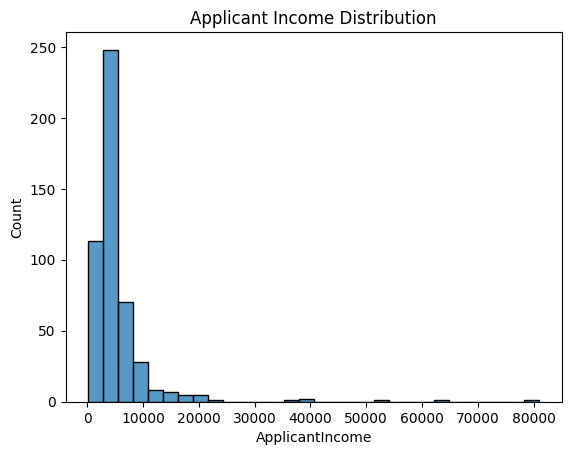

In [73]:
sns.histplot(df["ApplicantIncome"], bins=30)
plt.title("Applicant Income Distribution")
plt.show()

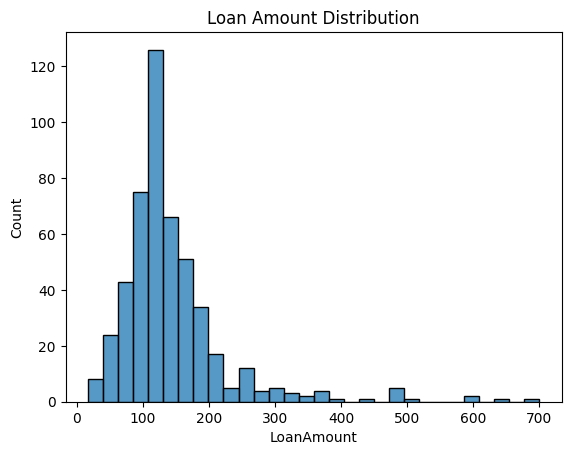

In [74]:
sns.histplot(df["LoanAmount"], bins=30)
plt.title("Loan Amount Distribution")
plt.show()

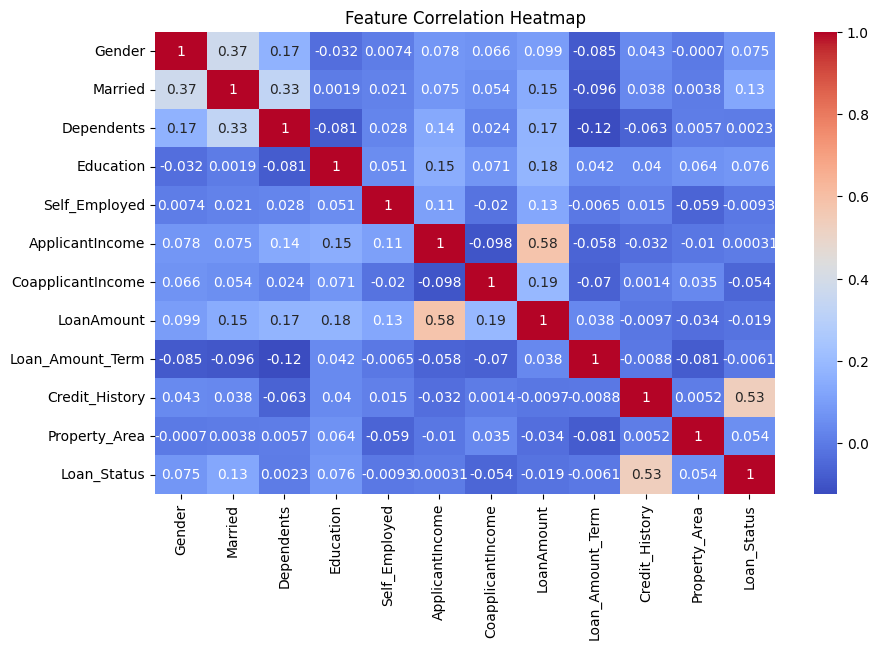

In [75]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()